### 0. Setup

In [ ]:
from helpers import *
import numpy as np
import matplotlib.pyplot as plt
import csv
import os

In [7]:
x_train, x_test, y_train, train_ids, test_ids = load_csv_data("/Users/majakubik/Documents/CSE/Machine Learning/project1_ml/data/dataset")

In [9]:
x_train.shape, x_test.shape

((328135, 321), (109379, 321))

### 1. Column names

In [ ]:
data_path = "/Users/majakubik/Documents/CSE/Machine Learning/project1_ml/data/dataset"

with open(os.path.join(data_path, "x_train.csv")) as f:
    reader = csv.reader(f)
    header = next(reader)

# remove index
header = header[1:]

# check header list size against shape od x_trian
if int(len(header)) == int(x_train.shape[1]): 
    print("Header okay!")

Header okay!


In [ ]:
# takes name as argument, return the data column for that name
def get_column_by_name(name):
    idx = header.index(name)
    column = x_train[:, idx]
    return column

In [28]:
# gives number of NaNs in each column
missing_cols = np.isnan(x_train).sum(axis=0)
print(missing_cols)

[     0      0      0      0      0      0      0      0      0 139415
 139415 328103 139416 139415 328103 139433 139524 139525 188720 188720
 188721 188720 327334 188719 189287 192544      2      1      0 159860
      0      0      1      1      1 196334      0  43801  43801      0
      0 284153      1      0      0      1      0      0      5 285915
      0      0      0      0 139415 318245 139415      1      0      3
   2471   3207   3946   4407 279663   6933   7743   8293   8728   9149
   9432   9862  10541 191379 282510 237369  11007  11765 170906 171212
 171522  20738  21567  22468  23149  23759  24502  26205 107829 109141
 109407 109690 181261 181400  28647 226907 227043 227197 229088  29911
  30600 186763 186001  31022  32080 243418 243561 266689 266689 306425
 306426 306428 306429 306429 306629 306429 306430 306430 247299 310302
 310320 310346 310367 310392 310403 310450 265347 325762 325769 325769
 327339 326264 325775 325777 325777 325780 241493 318477 318489 325051
 31850

In [ ]:
# x_train = np.delete(x_train, column_index, axis=1)
mask_mis = np.array(missing_cols).sum(axis = 0)
mask_mis = mask_mis > 300000
header_array = np.array(header)

print(header_array[mask_mis])

['COLGHOUS' 'LADULT' 'CCLGHOUS' 'NUMPHON2' 'INSULIN' 'BLDSUGAR' 'FEETCHK2'
 'DOCTDIAB' 'CHKHEMO3' 'FEETCHK' 'EYEEXAM' 'DIABEYE' 'DIABEDU' 'CRGVREL1'
 'CRGVLNG1' 'CRGVHRS1' 'CRGVPRB1' 'CRGVPERS' 'CRGVHOUS' 'CRGVMST2'
 'VIDFCLT2' 'VIREDIF3' 'VIPRFVS2' 'VINOCRE2' 'VIEYEXM2' 'VIINSUR2'
 'VICTRCT4' 'VIGLUMA2' 'VIMACDG2' 'CDHOUSE' 'CDASSIST' 'CDHELP' 'CDSOCIAL'
 'CDDISCUS' 'LONGWTCH' 'ASTHMAGE' 'ASATTACK' 'ASERVIST' 'ASDRVIST'
 'ASRCHKUP' 'ASACTLIM' 'ASYMPTOM' 'ASNOSLEP' 'ASTHMED3' 'ASINHALR'
 'HAREHAB1' 'STREHAB1' 'CVDASPRN' 'ASPUNSAF' 'RLIVPAIN' 'RDUCHART'
 'RDUCSTRK' 'ARTTODAY' 'ARTHWGT' 'ARTHEXER' 'ARTHEDU' 'HPVADVC2'
 'HPVADSHT' 'SHINGLE2' 'HADMAM' 'HOWLONG' 'HADPAP2' 'LASTPAP2' 'HPVTEST'
 'HPLSTTST' 'HADHYST2' 'PROFEXAM' 'LENGEXAM' 'LSTBLDS3' 'PCPSAAD2'
 'PCPSADI1' 'PCPSARE1' 'PSATEST1' 'PSATIME' 'PCPSARS1' 'PCPSADE1'
 'PCDMDECN' 'SCNTPAID' 'SCNTWRK1' 'SCNTLPAD' 'CASTHNO2' 'EMTSUPRT'
 'LSATISFY' 'ADPLEASR' 'ADDOWN' 'ADSLEEP' 'ADENERGY' 'ADEAT1' 'ADFAIL'
 'ADTHINK' 'ADMOVE' 'MISTMNT' 'A

In [41]:
# gives number of NaNs in each column
missing_rows = np.isnan(x_train).sum(axis=1)
missing_rows_300 = missing_rows <= 150

print(len(missing_rows[missing_rows_300]))

239566


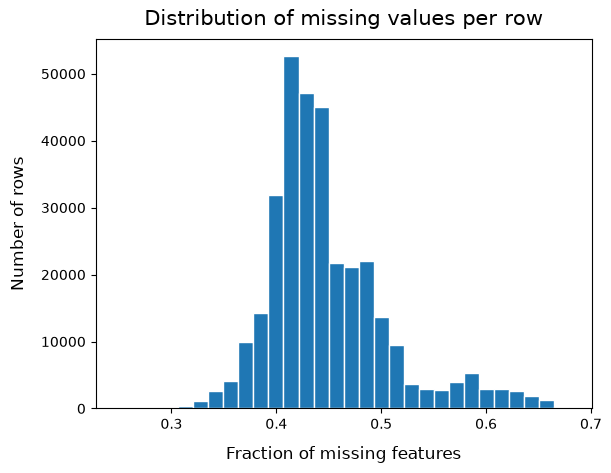

In [ ]:
frac_missing_rows = missing_rows / x_train.shape[1]

plt.hist(frac_missing_rows, bins=30, edgecolor="white")
plt.xlabel("Fraction of missing features", fontsize=12, labelpad=10)
plt.ylabel("Number of rows", fontsize=12, labelpad=10)
plt.title("Distribution of missing values per column", fontsize=15, pad=10)
plt.show()

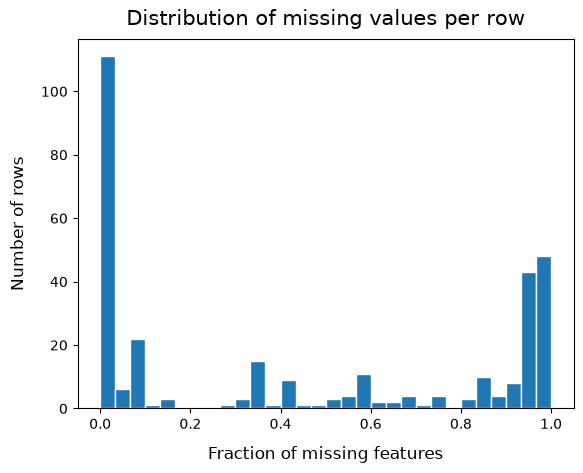

In [57]:
frac_missing_cols = missing_cols / x_train.shape[0]

plt.hist(frac_missing_cols, bins=30, edgecolor="white")
plt.xlabel("Fraction of missing features", fontsize=12, labelpad=10)
plt.ylabel("Number of rows", fontsize=12, labelpad=10)
plt.title("Distribution of missing values per row", fontsize=15, pad=10)
plt.show()